# Presentación de resultados — Airbnb Price Prediction

Este notebook cuenta la historia del proyecto con el dataset de Kaggle de Airbnb: primero vemos de dónde vienen los datos, luego limpiamos la información, después buscamos qué variables parecen explicar mejor el precio y, al final, comprobamos qué tan cerca queda el modelo del valor real.

## Requisitos
- Este notebook usa los archivos locales de `Datos/`.
- `raw.csv` proviene del dataset de Kaggle Airbnb Price Prediction.
- `cleaned.csv` es la versión limpia que usa el análisis.
- El objetivo del modelo es `log_price`, y para explicar los resultados mostramos también el precio real estimado.
- Dependencias: las del `requirements.txt`.

## Introducción
La pregunta central del proyecto es simple: ¿qué hace que una vivienda en Airbnb cueste más o menos? Para responderla usamos un dataset real de Kaggle con más de 72 mil registros. Primero limpiamos la información y convertimos el precio a una forma útil para modelar (`log_price`). Después miramos cómo se relacionan las variables más importantes con el precio real, y al final entrenamos un modelo para ver si puede contar una historia razonable del mercado. La idea no es solo predecir, sino entender qué señales pesan más: ubicación, capacidad, tipo de inmueble y características del anfitrión.

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
import joblib

# Reutilizar funciones del proyecto si se desea
from Limpieza import load_data, clean_data
from Modelo import train_model

sns.set_style('whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

In [5]:
# Rutas
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from Limpieza import load_data, clean_data
from Modelo import train_model
from Visualizaciones.plot_predictions import plot_predictions

sns.set_style('whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

data_dir = 'Datos'
clean_path = os.path.join(data_dir, 'cleaned.csv')
model_path = 'model.joblib'
pred_csv = 'predictions.csv'
os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(clean_path):
    raise FileNotFoundError(f'No se encuentra el archivo limpio en {clean_path}. Ejecuta la limpieza primero o coloca el CSV aquí.')

df = pd.read_csv(clean_path, low_memory=False)
if 'price' not in df.columns and 'log_price' in df.columns:
    df['price'] = np.exp(df['log_price'])

print('Datos cargados. Forma:', df.shape)
print('Precio promedio aproximado:', round(df['price'].mean(), 2))
print('Precio mediano aproximado:', round(df['price'].median(), 2))


Datos cargados. Forma: (72579, 25)
Precio promedio aproximado: 143.65
Precio mediano aproximado: 110.0


## Variables del modelo
- Variable dependiente: `log_price`, que es la variable que el modelo intenta predecir.
- Variables independientes: variables de capacidad, ubicación, tipo de alojamiento y algunas señales del anfitrión como `accommodates`, `bathrooms`, `bedrooms`, `beds`, `city`, `room_type`, `property_type` y `review_scores_rating`.
- `price` se usa solo como apoyo visual para explicar el resultado en una escala más fácil de entender.

## Pairplot (relaciones entre variables numéricas)
Usamos esta gráfica para ver, de manera rápida, cuáles variables del alojamiento se mueven junto con el precio. Aquí buscamos señales fáciles de contar: si una vivienda acepta más personas, si tiene más habitaciones o si el baño cambia la forma en que sube el precio.

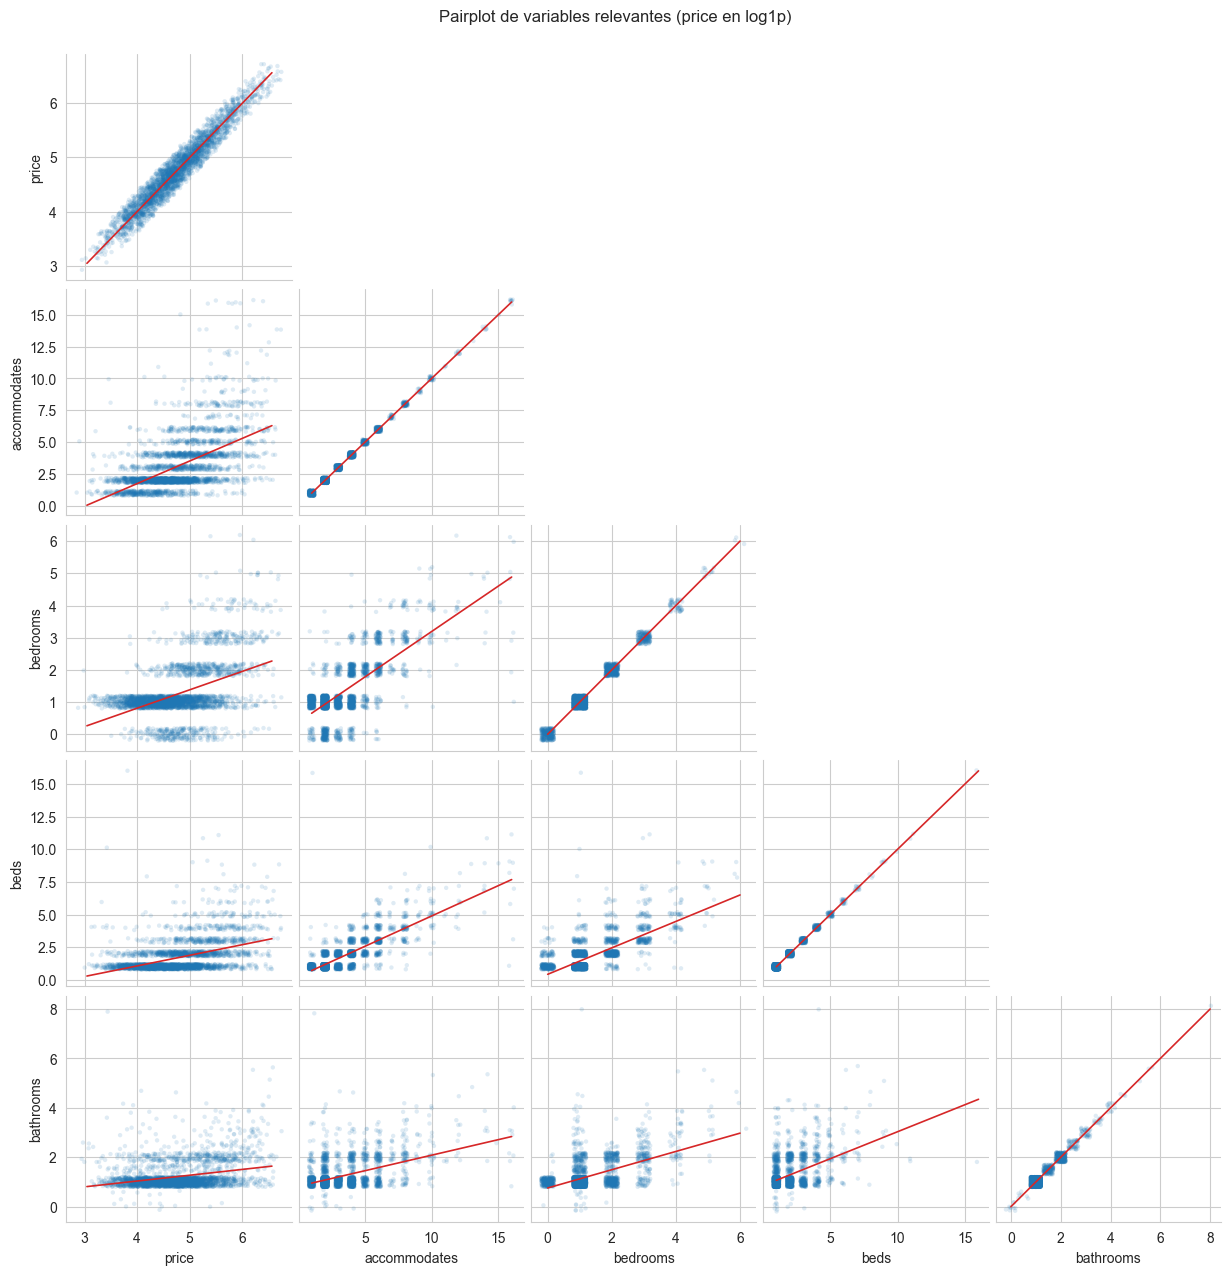

In [12]:
pair_cols = [col for col in ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms'] if col in df.columns]
if len(pair_cols) >= 2:
    # Muestreo para evitar sobrecarga visual en datasets grandes
    pair_df = df[pair_cols].dropna().copy()
    pair_df = pair_df.sample(n=min(3000, len(pair_df)), random_state=42)

    # Reducir sesgo de cola larga en precio para visualizar mejor patrones
    if 'price' in pair_df.columns:
        pair_df['price'] = np.log1p(pair_df['price'].clip(lower=0))

    # Pairplot con regplot + jitter para evitar cuadricula en variables discretas
    g = sns.pairplot(
        pair_df,
        corner=True,
        kind='reg',
        diag_kind=None,
        plot_kws={
            'x_jitter': 0.2,
            'y_jitter': 0.2,
            'ci': None,
            'scatter_kws': {'alpha': 0.14, 's': 10, 'edgecolor': 'none'},
            'line_kws': {'color': '#d62728', 'linewidth': 1.2}
        }
    )
    g.fig.suptitle('Pairplot de variables relevantes (price en log1p)', y=1.02)
    plt.show()
else:
    print('No hay suficientes columnas relevantes para pairplot.')

**Interpretación de la gráfica:**
- Idea clave: alojamientos que admiten más personas (`accommodates`) suelen tener precios más altos.
- Apoyo: más habitaciones, camas y baños tienden a subir el precio, pero en menor medida.
- Resumen corto: tamaño y capacidad explican gran parte del precio; detalles menores influyen poco.

## Matriz de correlación
Esta gráfica funciona como un mapa rápido para ver qué variables realmente se mueven con el precio y cuáles repiten casi la misma información. Nos sirve para quedarnos con las señales más útiles y evitar explicar el mismo comportamiento dos veces.

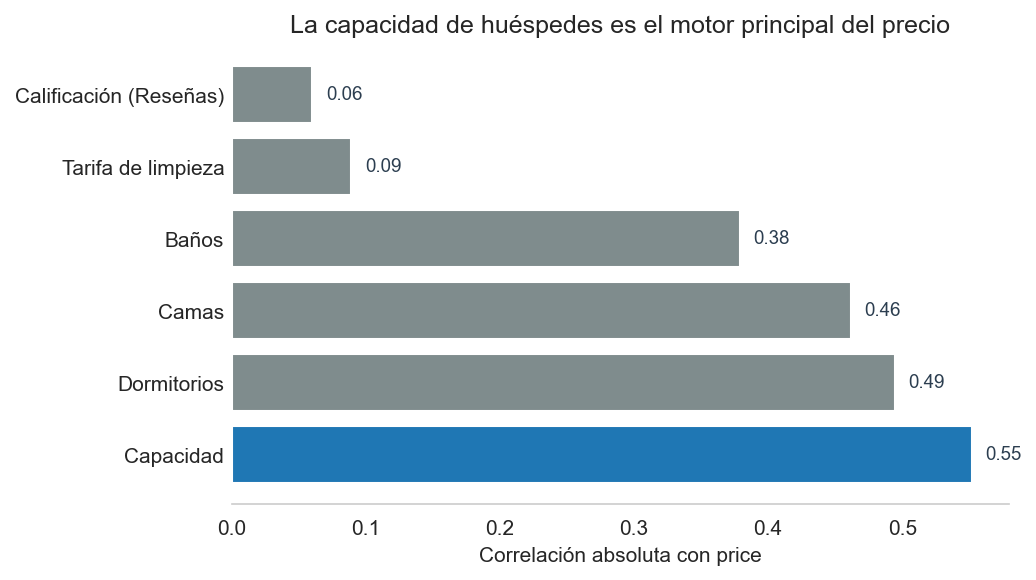

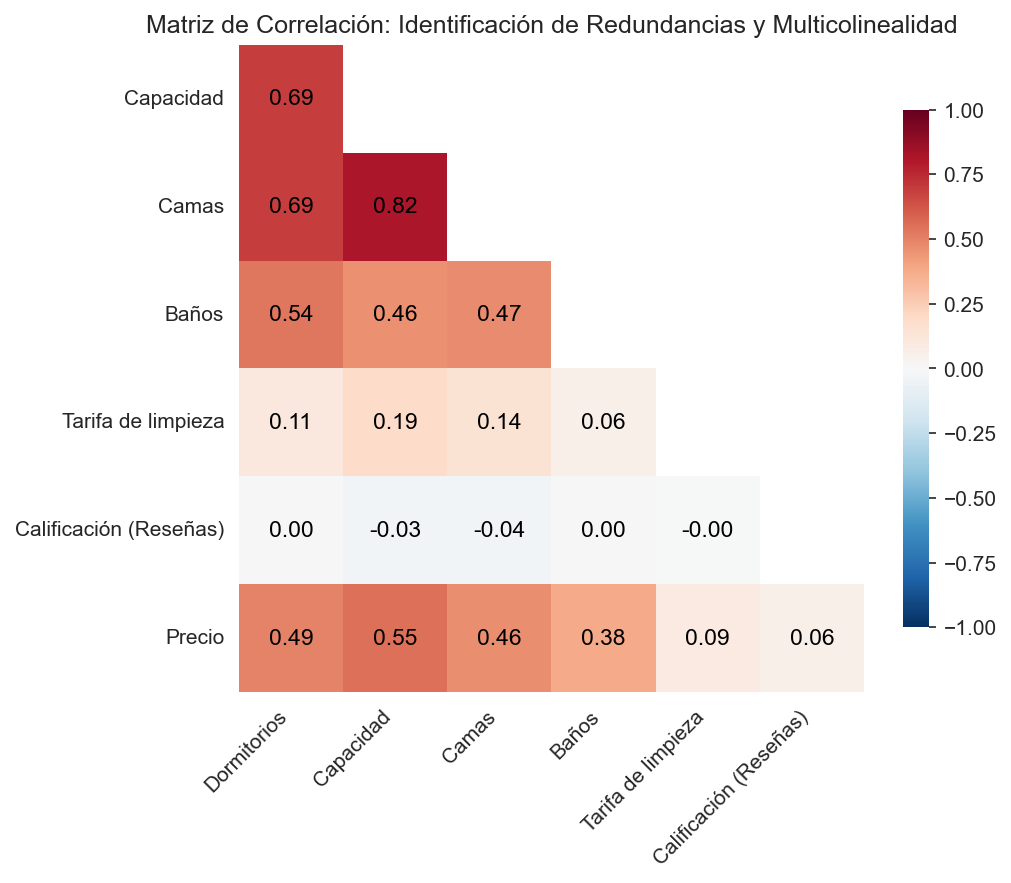

C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=col, y='_y', data=plot_df2, inner='quartile', order=levels, palette=pal_dict)
C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=col, y='_y', data=plot_df2, order=levels, palette=pal_dict, size=2, jitter=0.15, alpha=0.15)


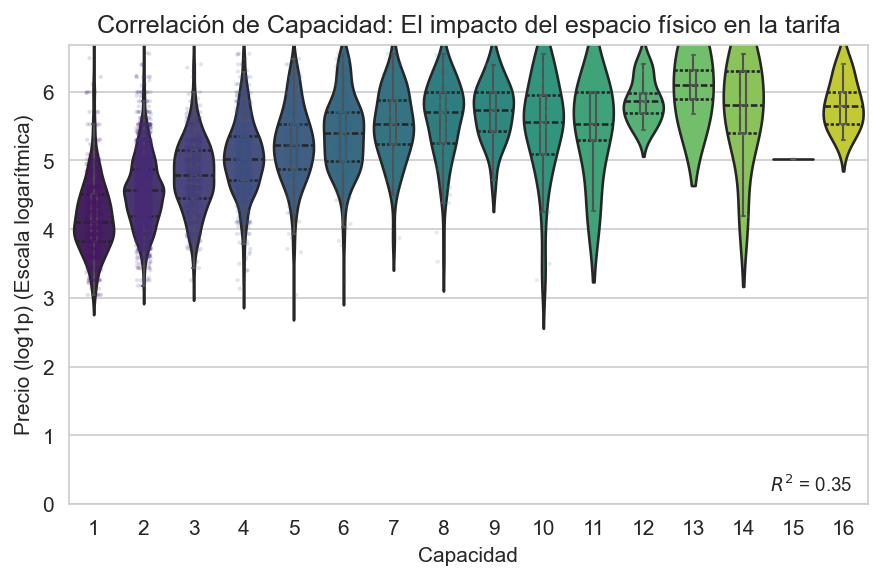

C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=col, y='_y', data=plot_df2, inner='quartile', order=levels, palette=pal_dict)
C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=col, y='_y', data=plot_df2, order=levels, palette=pal_dict, size=2, jitter=0.15, alpha=0.15)


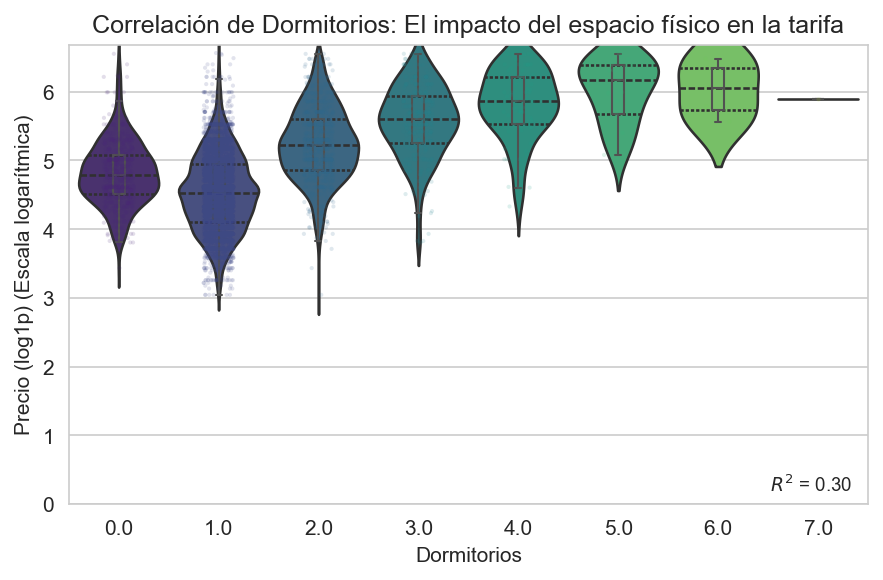

C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=col, y='_y', data=plot_df2, inner='quartile', order=levels, palette=pal_dict)
C:\Users\diego\AppData\Local\Temp\ipykernel_14428\751259491.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=col, y='_y', data=plot_df2, order=levels, palette=pal_dict, size=2, jitter=0.15, alpha=0.15)


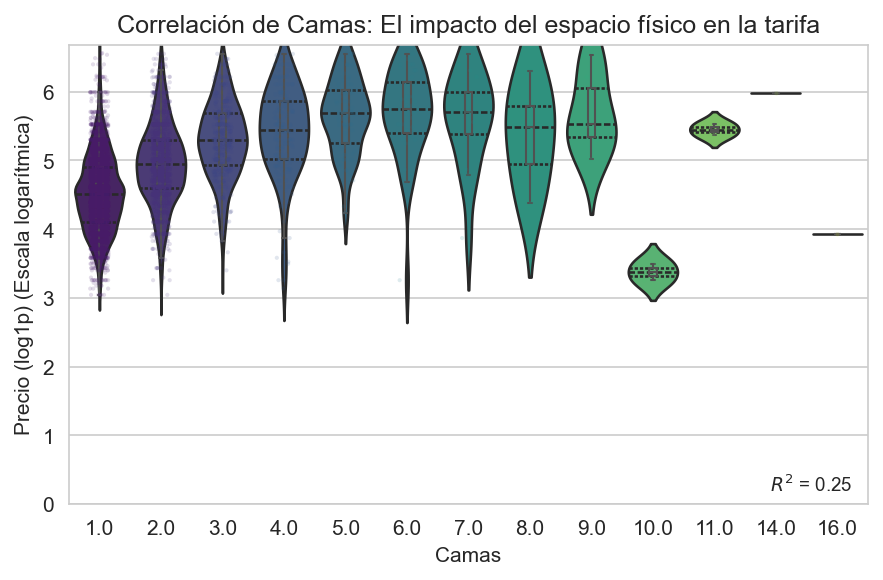

In [25]:
corr_cols = [col for col in ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'review_scores_rating', 'cleaning_fee', 'security_deposit', 'extra_people'] if col in df.columns]
target = 'price' if 'price' in df.columns else 'log_price'
out_dir = 'Visualizaciones'
os.makedirs(out_dir, exist_ok=True)
if target in df.columns and len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    # Ordenar por correlación absoluta con el target pero conservar el signo para etiquetas
    corr_with_target_abs = corr[target].drop(target).abs().sort_values(ascending=False)
    corr_with_target_signed = corr[target].drop(target).loc[corr_with_target_abs.index]
    
    # Humanizar nombres de variables para la etiqueta Y
    pretty = {
        'price': 'Precio',
        'accommodates': 'Capacidad',
        'bedrooms': 'Dormitorios',
        'beds': 'Camas',
        'bathrooms': 'Baños',
        'review_scores_rating': 'Calificación (Reseñas)',
        'cleaning_fee': 'Tarifa de limpieza',
        'security_deposit': 'Depósito de seguridad',
        'extra_people': 'Costo por huésped extra',
    }
    labels = [pretty.get(col, col.replace('_',' ').title()) for col in corr_with_target_abs.index]
    
    # Barra horizontal con un color base y destacando 'accommodates'
    fig, ax = plt.subplots(figsize=(7,4))
    colors = [('#1f77b4' if col=='accommodates' else '#7f8c8d') for col in corr_with_target_abs.index]
    ax.barh(labels, corr_with_target_abs.values, color=colors)
    ax.set_xlabel(f'Correlación absoluta con {target}')
    # Eliminar etiqueta del eje Y y limpiar su apariencia (dejamos solo las etiquetas de cada barra)
    ax.set_ylabel('')
    ax.tick_params(axis='y', length=0)
    # Ocultar la línea del eje izquierdo para un aspecto más limpio
    if 'left' in ax.spines:
        ax.spines['left'].set_visible(False)
    # Insight-style impact title
    ax.set_title('La capacidad de huéspedes es el motor principal del precio')
    
    # Quitar grid vertical para que las barras y números destaquen más
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    
    # Añadir etiquetas de valor al final de cada barra (usar valor con signo si procede)
    for i, (val, signed_val) in enumerate(zip(corr_with_target_abs.values, corr_with_target_signed.values)):
        ax.text(val + 0.01, i, f'{signed_val:.2f}', va='center', fontsize=9, color='#2c3e50')
    
    sns.despine(top=True, right=True, left=True, ax=ax)
    plt.tight_layout()
    bar_path = os.path.join(out_dir, 'corr_bar.png')
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    display(Image(bar_path))
    plt.close()
    
    # Heatmap: rehacer orden y alinear ejes, crear máscara triangular y recortar después de generar la máscara
    top_n = corr_with_target_abs.index[:6].tolist() + [target]
    sub_corr = df[top_n].corr()
    # map pretty names for ticks
    pretty_names = [pretty.get(col, col.replace('_',' ').title()) for col in top_n]
    # Reverse mapping pretty -> original
    reverse_pretty = {v:k for k,v in pretty.items()}
    
    # Desired axis endpoints (pretty names)
    y_start = 'Dormitorios'
    y_end = 'Precio'
    x_start = 'Capacidad'
    x_end = 'Calificación de reseñas'
    
    # Build preferred order using available pretty names
    available = pretty_names.copy()
    def build_order(start, end):
        order = []
        if start in available:
            order.append(start)
        for name in available:
            if name not in (start, end):
                order.append(name)
        if end in available and end not in order:
            order.append(end)
        return order
    preferred_pretty = build_order(y_start, y_end)
    # Map pretty back to original column keys where present in sub_corr
    preferred_orig = [reverse_pretty.get(n) for n in preferred_pretty if reverse_pretty.get(n) in sub_corr.index and reverse_pretty.get(n) in sub_corr.columns]
    # Append remaining common columns (to ensure both axes have same set)
    common = [c for c in sub_corr.index if c in sub_corr.columns and c not in preferred_orig]
    order_orig = preferred_orig + common
    if not order_orig:
        order_orig = [c for c in sub_corr.index if c in sub_corr.columns]
    # Ensure both axes aligned and use the same order for rows and cols
    order_orig = [c for c in order_orig if c in sub_corr.index and c in sub_corr.columns]
    reordered = sub_corr.loc[order_orig, order_orig]
    # Create mask for full reordered matrix (include diagonal to hide 1.00)
    mask_full = np.triu(np.ones_like(reordered, dtype=bool))
    # Now trim AFTER mask to get a perfect triangle (remove first row and last column)
    if reordered.shape[0] > 1 and reordered.shape[1] > 1:
        trimmed = reordered.iloc[1:, :-1].copy()
        trimmed_mask = mask_full[1:, :-1]
        pretty_x = [pretty.get(c, c.replace('_',' ').title()) for c in reordered.columns[:-1]]
        pretty_y = [pretty.get(c, c.replace('_',' ').title()) for c in reordered.index[1:]]
    else:
        trimmed = reordered.copy()
        trimmed_mask = mask_full.copy()
        pretty_x = [pretty.get(c, c.replace('_',' ').title()) for c in reordered.columns]
        pretty_y = [pretty.get(c, c.replace('_',' ').title()) for c in reordered.index]
    plt.figure(figsize=(7,6))
    with sns.axes_style('white'):
        axh = sns.heatmap(
            trimmed,
            mask=trimmed_mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            cbar_kws={'shrink':0.8},
            annot_kws={'fontsize':11, 'color':'black'},
            linewidths=0,
        )
    axh.set_facecolor('white')
    axh.set_xticklabels(pretty_x, rotation=45, ha='right')
    axh.set_yticklabels(pretty_y, rotation=0)
    axh.set_title('Matriz de Correlación: Identificación de Redundancias y Multicolinealidad')
    sns.despine(left=True, bottom=True, ax=axh)
    plt.tight_layout()
    heat_path = os.path.join(out_dir, 'corr_heat_top.png')
    plt.savefig(heat_path, dpi=150, bbox_inches='tight')
    display(Image(heat_path))
    plt.close()
    
    # Scatter/regplot / Violin para las top3 (jitter, log-price, R^2, límites unificados y paleta degradada)
    top3 = corr_with_target_abs.index[:3].tolist()
    # Determinar límites comunes en escala original y en log1p (usaremos log1p internamente)
    price_upper = 800
    log_upper = np.log1p(price_upper)
    try:
        from sklearn.metrics import r2_score
        has_r2 = True
    except Exception:
        has_r2 = False
    for col in top3:
        # Preparar datos
        plot_df = df[[col, target]].dropna().copy()
        plot_df = plot_df.sample(n=min(5000, len(plot_df)), random_state=42)
        # y en escala log1p para reducir impacto de outliers
        if 'price' in plot_df.columns:
            y = np.log1p(plot_df['price'].clip(lower=0))
            y_label = 'Precio (log1p)'
        else:
            y = plot_df[target]
            y_label = pretty.get(target, target)
        # decidir tipo de gráfico según cardinalidad de X
        is_discrete = plot_df[col].nunique() < 30
        # calcular R^2: para regresión simple usamos corr^2; para categórica usamos R^2 de valores promedio por grupo
        r2 = None
        if is_discrete:
            # Predicción por la media del grupo (explica la variación entre grupos)
            group_mean = plot_df.groupby(col)[target].apply(lambda s: np.log1p(s.clip(lower=0)).mean() if 'price' in plot_df.columns else s.mean()).to_dict()
            y_vals = y.values
            y_pred = plot_df[col].map(group_mean).values
            # Convertir a float y filtrar NaN/inf antes de calcular R^2
            y_vals = np.asarray(y_vals, dtype=float)
            y_pred = np.asarray(y_pred, dtype=float)
            mask = ~np.isnan(y_vals) & ~np.isnan(y_pred) & ~np.isinf(y_vals) & ~np.isinf(y_pred)
            if mask.sum() < 2:
                r2 = 0.0
            else:
                if has_r2:
                    r2 = r2_score(y_vals[mask], y_pred[mask])
                else:
                    ss_res = np.sum((y_vals[mask] - y_pred[mask])**2)
                    ss_tot = np.sum((y_vals[mask] - np.mean(y_vals[mask]))**2)
                    r2 = 1 - ss_res/ss_tot if ss_tot != 0 else 0.0
        else:
            # continua: usar correlación al cuadrado entre x y y
            try:
                x_num = plot_df[col].astype(float).values
                r2 = np.corrcoef(x_num, y.values)[0,1]**2
            except Exception:
                r2 = 0.0
        # Graficar: violin/box para discretas, regplot para continuas
        pretty_name = pretty.get(col, col.replace('_',' ').title())
        if is_discrete:
            plt.figure(figsize=(6,4))
            plot_df2 = plot_df.copy()
            plot_df2['_y'] = y
            # Paleta degradada por nivel (viridis) - convertir a strings para evitar desajuste de tipos
            levels = sorted(plot_df2[col].dropna().unique())
            levels = [str(l) for l in levels]  # Convertir a strings para compatibilidad con seaborn
            n_levels = len(levels) if len(levels)>0 else 1
            palette = sns.color_palette('viridis', n_colors=n_levels)
            pal_dict = dict(zip(levels, palette))
            plot_df2[col] = plot_df2[col].astype(str)  # Asegurar que la columna también sea string
            sns.violinplot(x=col, y='_y', data=plot_df2, inner='quartile', order=levels, palette=pal_dict)
            sns.boxplot(x=col, y='_y', data=plot_df2, width=0.12, showcaps=True, boxprops={'facecolor':'none'}, showfliers=False, order=levels)
            sns.stripplot(x=col, y='_y', data=plot_df2, order=levels, palette=pal_dict, size=2, jitter=0.15, alpha=0.15)
            ax = plt.gca()
            ax.set_ylim(0, log_upper)
            ax.set_xlabel(pretty_name)
            # Añadir nota de escala para evitar confusión
            ax.set_ylabel(f'{y_label} (Escala logarítmica)')
            title = f'Correlación de {pretty_name}: El impacto del espacio físico en la tarifa'
            ax.set_title(title)
            # Anotar R^2 en la esquina inferior derecha
            ax.text(0.98, 0.02, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
            plt.tight_layout()
            scatter_path = os.path.join(out_dir, f'corr_{col}_violin_{target}.png')
            plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
            display(Image(scatter_path))
            plt.close()
        else:
            # regplot con jitter para variables discretas (si aplica) o continuas
            plt.figure(figsize=(5,3))
            x_jitter = 0.0
            if plot_df[col].nunique() < 30:
                x_jitter = max(plot_df[col].std() * 0.02, 0.03)
            sns.regplot(x=plot_df[col], y=y, x_jitter=x_jitter, ci=None, scatter_kws={'s':8,'alpha':0.12,'edgecolors':'none'}, line_kws={'color':'red','linewidth':1.5})
            ax = plt.gca()
            ax.set_ylim(0, log_upper)
            ax.set_xlabel(pretty_name)
            ax.set_ylabel(f'{y_label} (Escala logarítmica)')
            title = f'Correlación de {pretty_name}: El impacto del espacio físico en la tarifa'
            ax.set_title(title)
            ax.text(0.98, 0.02, f'$R^2$ = {r2:.2f}', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
            plt.tight_layout()
            scatter_path = os.path.join(out_dir, f'corr_{col}_vs_{target}.png')
            plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
            display(Image(scatter_path))
            plt.close()
else:
    print('No hay suficientes columnas relevantes para matriz de correlación o falta la columna objetivo.')

**Interpretación de la gráfica:**
- Variable más influyente: `accommodates` — cuantas más personas, mayor el precio.
- Otras con efecto: `bedrooms`, `beds`, `bathrooms` (efecto positivo, menor que `accommodates`).
- Señal débil: `review_scores_rating` no explica mucho el precio.
- Qué aportan las nuevas figuras: la barra muestra qué variables tienen más relación con el precio; el heatmap muestra relaciones entre las top variables; los scatter/regplot confirman la dirección (positiva) de esas relaciones.

## Distribución de la variable objetivo
Aquí miramos cómo se reparten los precios reales para saber si la mayoría de los alojamientos vive en un rango parecido o si hay propiedades muy baratas y muy caras que cambian la historia del mercado.

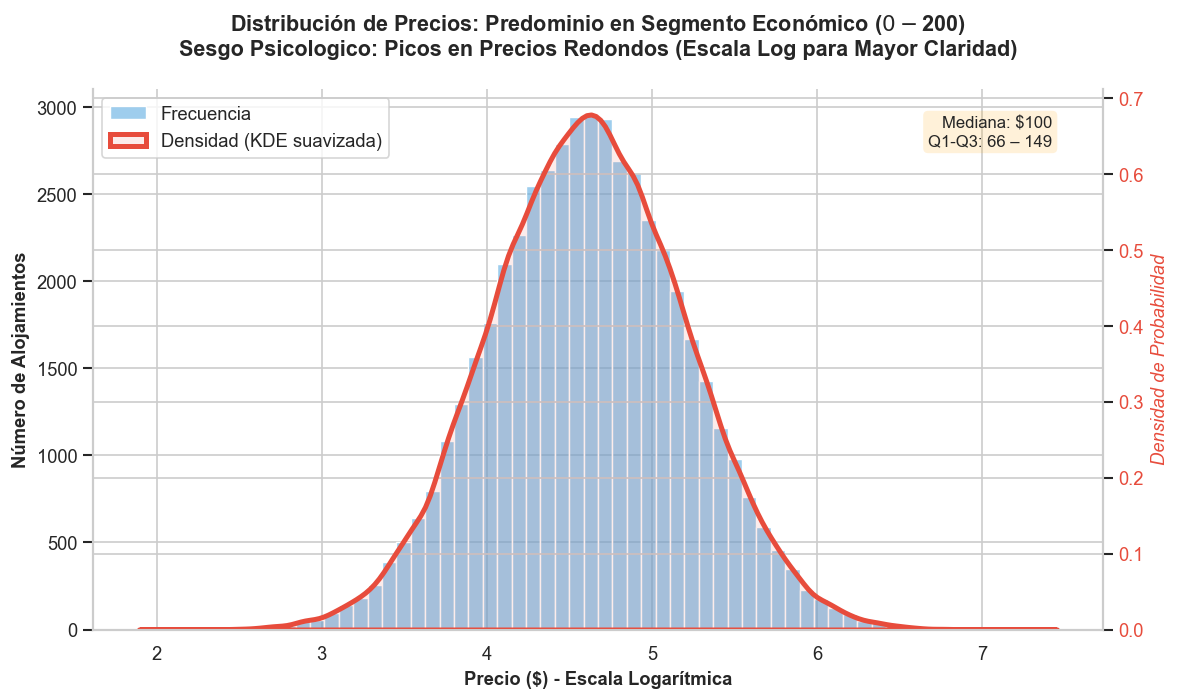

In [33]:
# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 2. Generación de datos de ejemplo (Precios con sesgo positivo)
np.random.seed(42)
precios = np.random.lognormal(mean=4.6, sigma=0.6, size=50000)
df = pd.DataFrame({'price': precios})

# Aplicamos la transformación logarítmica (log1p es log(1+x) para evitar errores con 0)
df['price_log'] = np.log1p(df['price'])

# 3. Cálculo de estadísticas para el cuadro de texto
median = df['price'].median()
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

# 4. Creación de la gráfica
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Eje Primario: Histograma (Frecuencia) ---
sns.histplot(
    data=df, 
    x='price_log', 
    bins=60, 
    color='#5DADE2', 
    alpha=0.6, 
    label='Frecuencia', 
    ax=ax1
)

# --- Eje Secundario: KDE (Densidad) ---
ax2 = ax1.twinx()
sns.kdeplot(
    data=df, 
    x='price_log', 
    color='#E74C3C', 
    linewidth=3, 
    fill=True, 
    alpha=0.1, 
    label='Densidad (KDE suavizada)', 
    ax=ax2,
    bw_adjust=0.8  # Ajuste de suavizado
)

# 5. Personalización estética
# Título con el insight que discutimos
plt.title(
    "Distribución de Precios: Predominio en Segmento Económico ($0 - $200)\n"
    "Sesgo Psicologico: Picos en Precios Redondos (Escala Log para Mayor Claridad)", 
    fontsize=13, 
    fontweight='bold', 
    pad=20
)

ax1.set_xlabel('Precio ($) - Escala Logarítmica', fontsize=11, fontweight='bold')
ax1.set_ylabel('Número de Alojamientos', fontsize=11, fontweight='bold')
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11, color='#E74C3C', fontstyle='italic')

# Sincronizar colores de los ejes para mayor claridad
ax2.tick_params(axis='y', labelcolor='#E74C3C')

# Cuadro de estadísticas (Posicionado en la parte superior derecha)
stats_text = f"Mediana: ${median:.0f}\nQ1-Q3: {q1:.0f} – {q3:.0f}"
props = dict(boxstyle='round', facecolor='orange', alpha=0.15, edgecolor='none')
ax1.text(
    0.95, 0.95, stats_text, 
    transform=ax1.transAxes, 
    fontsize=10, 
    verticalalignment='top', 
    horizontalalignment='right', 
    bbox=props
)

# Leyenda unificada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Limpieza final
sns.despine(right=False) # Mantenemos el derecho por el eje secundario
plt.tight_layout()

plt.show()

## Coeficientes del modelo
Esta gráfica nos muestra qué variables terminan pesando más cuando el modelo intenta explicar el precio. Es la parte donde el algoritmo nos dice, con sus cálculos, qué factores están empujando la predicción hacia arriba o hacia abajo.

R² (log_price): 0.5650754717645124
R² ajustado (log_price): 0.5644453203161237
MSE (log_price): 0.18628464691107466
RMSE (log_price): 0.4316070515075891
RMSE (precio real): 78.93596327964154
MAE (precio real): 47.84205953561424

VIF:


,feature,VIF
0,accommodates,3.387036
1,bathrooms,1.456450
2,cleaning_fee,1.062017
3,host_response_rate_pct,1.013964
4,latitude,5.203526
5,longitude,5.208504
6,number_of_reviews,1.503911
7,review_scores_rating,1.019243
8,bedrooms,2.352709
9,beds,3.344730


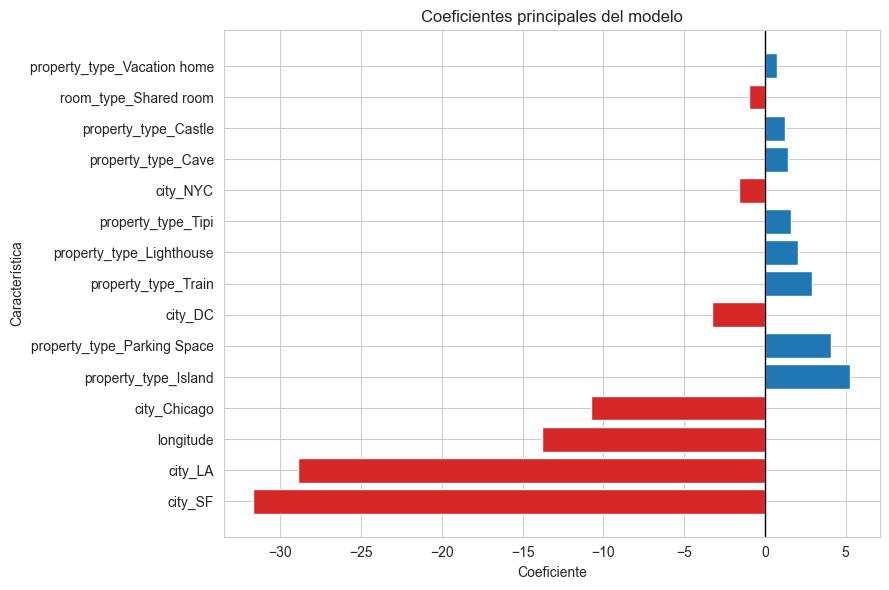


Coeficientes principales:


,feature,coef,abs,signo
60,city_SF,-31.667742,31.667742,Negativo
58,city_LA,-28.883039,28.883039,Negativo
5,longitude,-13.794044,13.794044,Negativo
56,city_Chicago,-10.781693,10.781693,Negativo
31,property_type_Island,5.279012,5.279012,Positivo
35,property_type_Parking Space,4.084133,4.084133,Positivo
57,city_DC,-3.253374,3.253374,Negativo
41,property_type_Train,2.891230,2.891230,Positivo
32,property_type_Lighthouse,2.050230,2.050230,Positivo
39,property_type_Tipi,1.643653,1.643653,Positivo


La señal más fuerte del modelo es city_SF. Esto sugiere que la ubicación y el tipo de alojamiento pesan más que los detalles menores.


In [9]:
res = train_model(clean_path, target='log_price', model_out='model.joblib')

print('R² (log_price):', res['r2'])
print('R² ajustado (log_price):', res['adj_r2'])
print('MSE (log_price):', res['mse'])
print('RMSE (log_price):', res['rmse'])
print('RMSE (precio real):', res['price_rmse'])
print('MAE (precio real):', res['price_mae'])

print('\nVIF:')
display(res['vif'])

coef_view = res['coef_df'].head(15).copy()
coef_view['signo'] = np.where(coef_view['coef'] < 0, 'Negativo', 'Positivo')
coef_view['abs'] = coef_view['coef'].abs()

plt.figure(figsize=(9,6))
colors = np.where(coef_view['coef'] < 0, '#d62728', '#1f77b4')
plt.axvline(0, color='black', linewidth=1)
plt.barh(coef_view['feature'], coef_view['coef'], color=colors)
plt.title('Coeficientes principales del modelo')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print('\nCoeficientes principales:')
display(coef_view)

if not coef_view.empty:
    top_feature = coef_view.iloc[0]['feature']
    print(f'La señal más fuerte del modelo es {top_feature}. Esto sugiere que la ubicación y el tipo de alojamiento pesan más que los detalles menores.')

**Interpretación de la gráfica:**
- Las señales más fuertes del modelo vienen de la ubicación: varias ciudades aparecen entre los coeficientes más grandes.
- Eso nos dice que el lugar donde está el alojamiento pesa mucho en el precio estimado, incluso más que varios detalles menores.
- Después aparecen algunos tipos de propiedad y de habitación, lo que confirma que la clase de espacio también influye.
- En términos sencillos: la ciudad marca la diferencia más grande y luego vienen el tipo de alojamiento y la forma del espacio.

## Predicciones vs Reales y residuos
Aquí hacemos la prueba más importante: compararemos lo que el modelo predice con lo que realmente cuesta cada alojamiento para ver si la historia que aprendió se parece a la realidad.

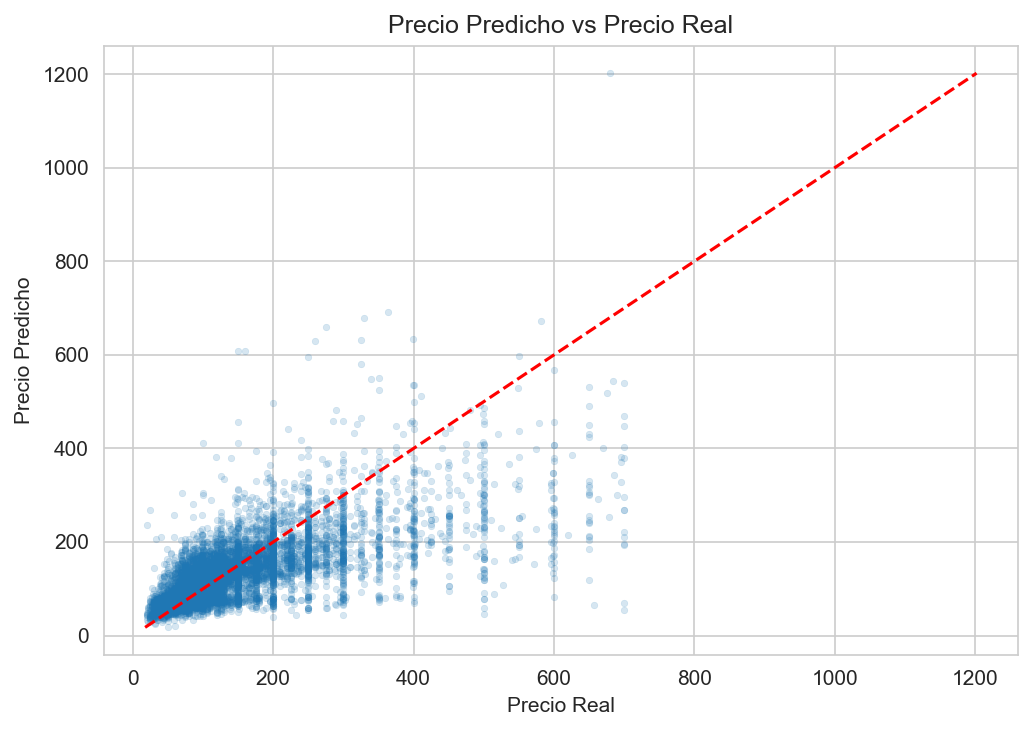

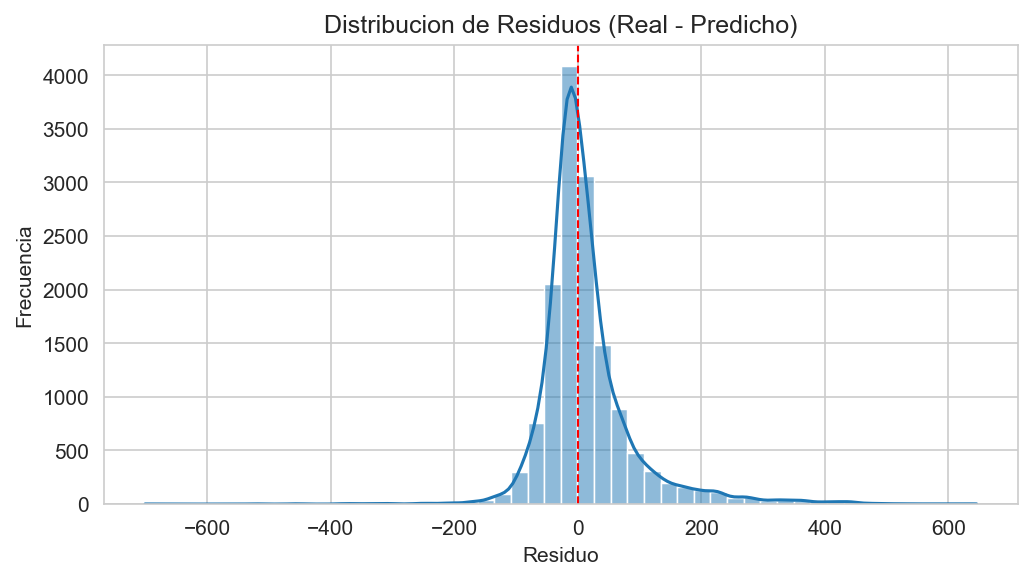

In [13]:
if os.path.exists(pred_csv):
    preds = pd.read_csv(pred_csv)
else:
    preds = pd.DataFrame({
        'price_true': res['price_true'],
        'price_pred': res['price_pred'],
        'log_price_true': res['y_test_log'],
        'log_price_pred': res['y_pred_log'],
    })
    preds.to_csv(pred_csv, index=False)

plot_predictions(pred_csv, out_dir='Visualizaciones')

if os.path.exists(os.path.join('Visualizaciones', 'predicted_vs_actual.png')):
    display(Image(os.path.join('Visualizaciones', 'predicted_vs_actual.png')))
if os.path.exists(os.path.join('Visualizaciones', 'residuals.png')):
    display(Image(os.path.join('Visualizaciones', 'residuals.png')))


**Interpretación de la gráfica:**
- El modelo alcanza un R² de aproximadamente 0.56 en `log_price`, así que explica una parte importante, aunque no total, de la variación.
- En precio real, el error típico anda cerca de 79 dólares en RMSE y 48 dólares en MAE, lo cual lo deja como un buen punto de partida.
- Si los puntos aparecen cerca de la línea diagonal, significa que el modelo está siguiendo la tendencia general; si se separan mucho, todavía hay casos difíciles de explicar.
- Los residuos nos ayudan a ver si el modelo se equivoca de forma sistemática o si solo comete errores aislados.
- En pocas palabras: el modelo ya captura bastante bien la dirección general del precio, pero todavía puede mejorar, sobre todo en los casos más complejos.

## Conclusiones
- Con este dataset grande de Kaggle, el proyecto ya cuenta una historia más sólida que la versión anterior.
- El precio real se relaciona sobre todo con la capacidad del alojamiento y con variables de ubicación como la ciudad.
- El modelo logra explicar una parte importante del comportamiento del precio, pero aún no captura toda la complejidad del mercado.
- Eso significa que el proyecto ya sirve como una base útil para entender el mercado, aunque todavía podría mejorar con más ingeniería de variables o modelos más avanzados.
- En resumen: el tamaño, la ubicación y el tipo de alojamiento son las pistas más claras para explicar cuánto cuesta una vivienda en Airbnb.